# Customer Churn Prediction

**Business objective:** Predict which telecom customers are likely to churn so the business can prioritize retention efforts.


In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [151]:
churn_data = pd.read_csv('../data/telco_churn.csv')
churn_data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 1. Inspecting Dataset

### 1.1 Displaying top-5 rows

In [152]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Displaying Bottom-5 rows

In [153]:
churn_data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### 1.3 Checking the shape of the dataset

In [154]:
overall_shape = churn_data.shape
print(f"Overall shape of the dataset (rows, cols): {overall_shape}")
print(f"No.of rows: {overall_shape[0]}")
print(f"No.of cols: {overall_shape[1]}")

Overall shape of the dataset (rows, cols): (7043, 21)
No.of rows: 7043
No.of cols: 21


### 1.4 Getting the information about the dataset

In [155]:
churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 1.5 Getting the overall statistics of the data

In [156]:
churn_data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### 1.6 Checking overall columns

In [157]:
churn_data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### 1.7 Checking for missing values

In [158]:
churn_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 1.8 Checking duplicate values

In [159]:
churn_data.duplicated().sum()

np.int64(0)

## 2. Data Cleaning

In [160]:
churn_cleaned = churn_data.copy()

In [161]:
churn_cleaned.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [162]:
# Convert TotalCharges to numeric (coerce errors to NaN)
churn_cleaned['TotalCharges'] = pd.to_numeric(churn_cleaned['TotalCharges'], errors='coerce')

In [163]:
# Check missing values again
churn_cleaned.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [164]:
rows_before = len(churn_cleaned)

churn_cleaned = churn_cleaned.dropna()

rows_removed = rows_before - len(churn_cleaned)
print(f"Rows removed because of missing TotalCharges: {rows_removed}")
print(f"Remaining rows for modelling: {len(churn_cleaned)}")

Rows removed because of missing TotalCharges: 11
Remaining rows for modelling: 7032


`TotalCharges` is stored as text and contains 11 blank values. It is converted to numeric, and the 11 affected rows are removed because they represent only 0.16% of the data. The model dataset therefore contains 7,032 customers.

In [165]:
churn_cleaned = churn_cleaned.drop('customerID', axis=1) # Drop customerID it's just a unique identifier, not a feature

In [166]:
churn_cleaned = churn_cleaned.reset_index(drop=True) # Reset index

## 3. EDA - Exploratory Data Analysis

### 3.1 Target Distribution (Class Imbalance Check)

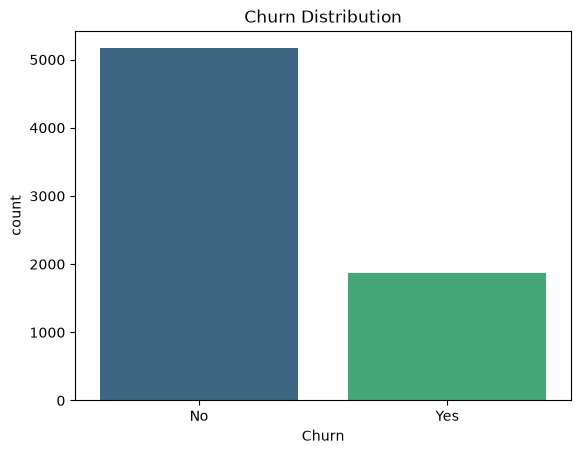

In [167]:
churn_cleaned['Churn'].value_counts(normalize=True)
sns.countplot(data=churn_cleaned, x='Churn', palette='viridis')
plt.title('Churn Distribution')
plt.show()

### 3.2 Numerical Features vs Churn

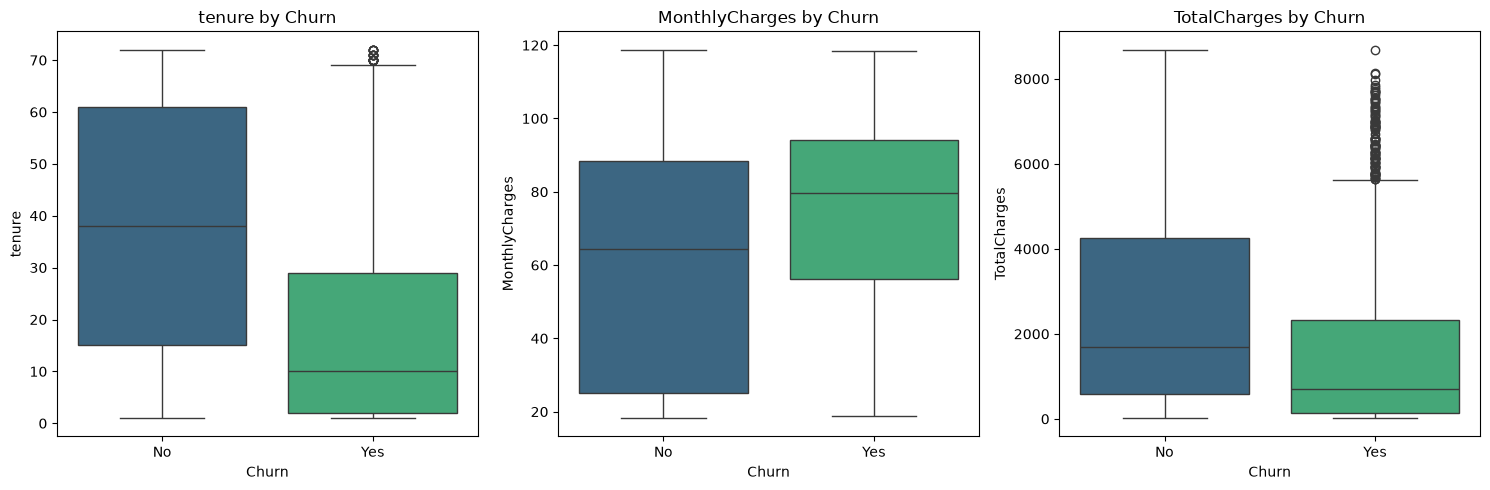

In [168]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(
        data=churn_cleaned,
        x='Churn',
        y=col,
        hue='Churn',
        palette='viridis',
        legend=False
    )
    
    plt.title(f'{col} by Churn')

plt.tight_layout()
plt.show()

> Insights:
- Tenure: Churned customers usually have lower tenure
- MonthlyCharges: Churned customers tend to pay more per month
- TotalCharges: Churned customers have lower total charges (because they left early)

### 3.3 Categorical Features vs Churn

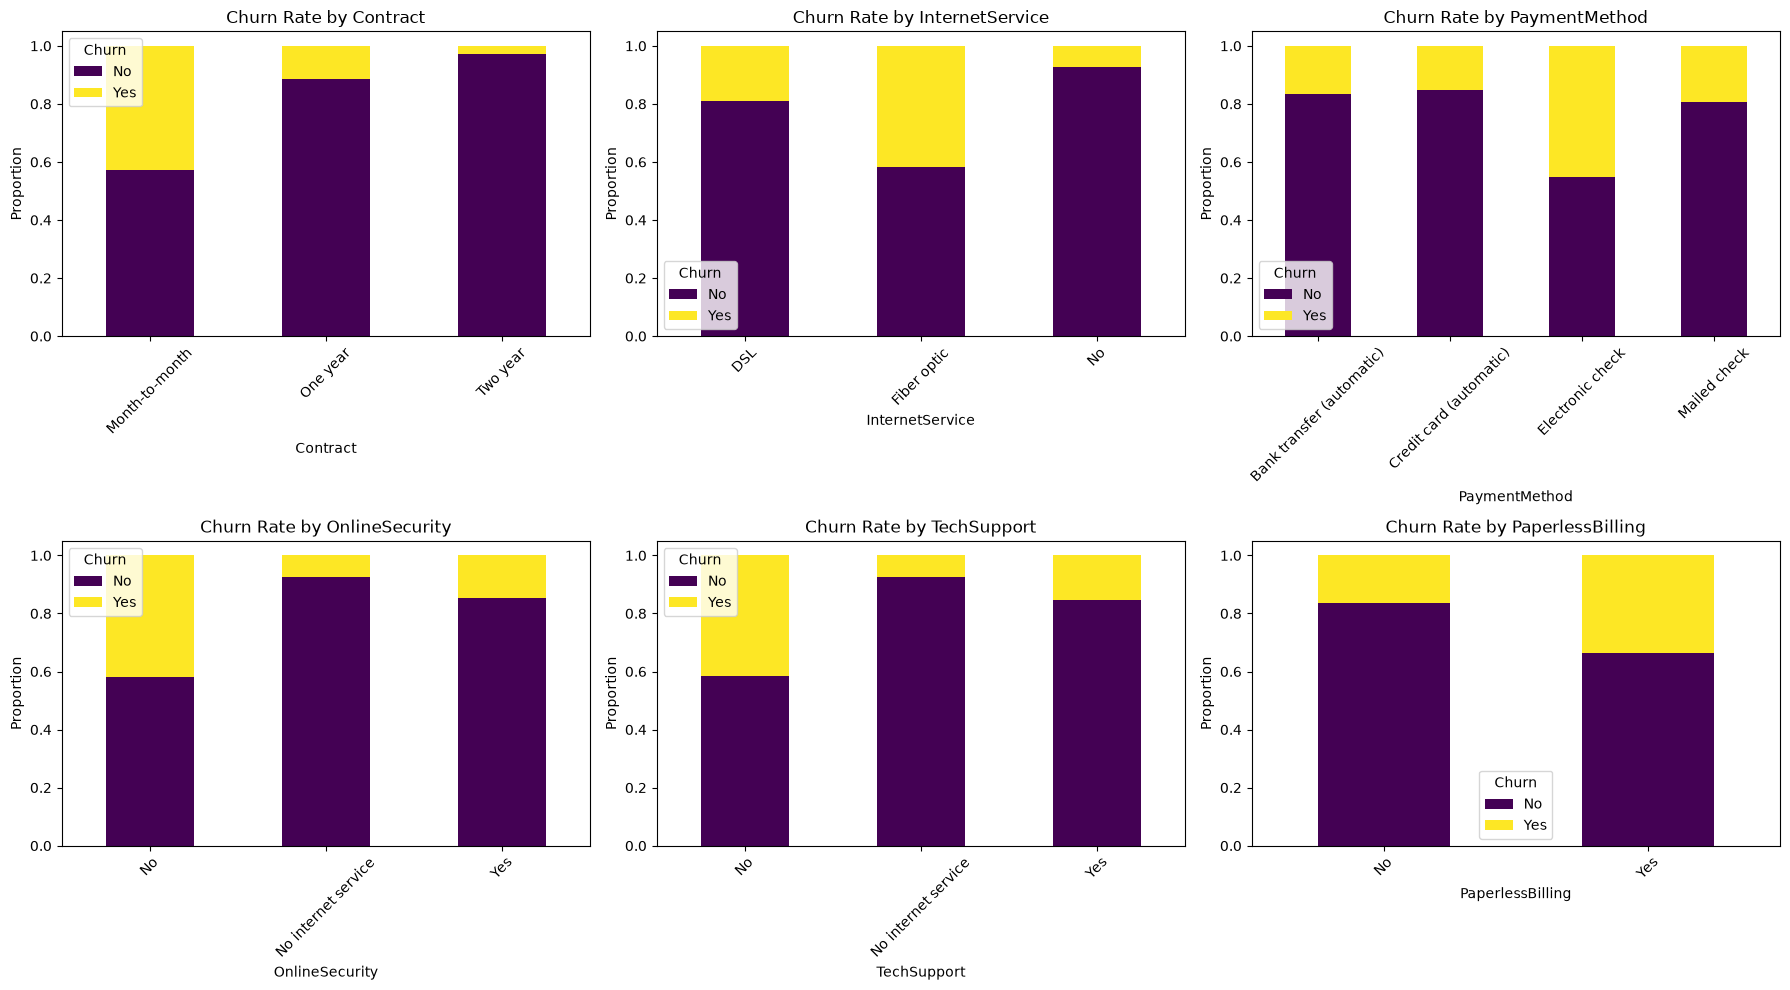

In [169]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

plt.figure(figsize=(18, 10))
for i, col in enumerate(cat_features, 1):

    ct = pd.crosstab(churn_cleaned[col], churn_cleaned['Churn'], normalize='index')

    ax = plt.subplot(2, 3, i)
    ct.plot(kind='bar', stacked=True, colormap='viridis', ax=ax)

    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Proportion')
    plt.xlabel(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

> Insight
- Contract: Month-to-month contracts have much higher churn
- InternetService: Fiber optic customers churn more
- PaymentMethod: Electronic check users churn more
- OnlineSecurity/TechSupport: Customers without these services churn more

### 3.4 Correlation Heatmap (Numerical)

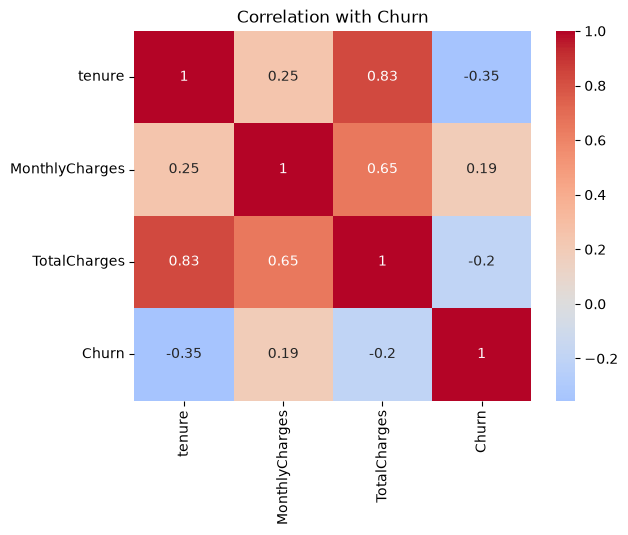

In [170]:
# Encode Churn temporarily for correlation
df_temp = churn_cleaned.copy()
df_temp['Churn'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

corr = df_temp[num_features + ['Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Churn')
plt.show()

## 4. Feature Engineering — Handle Categorical Variables

### 4.1 Encode the Target Variable `Churn`

In [171]:
churn_cleaned['Churn'] = churn_cleaned['Churn'].map({'Yes': 1, 'No': 0})

### 4.2 Separate Binary vs Multi-Category Features

In [172]:
# Binary categorical columns (Yes/No or Male/Female)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Multi-category columns (need One-Hot Encoding)
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

### 4.3 Label Encode Binary Columns

In [173]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_cols:
    churn_cleaned[col] = le.fit_transform(churn_cleaned[col])

In [174]:
churn_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### 4.4 One-Hot Encode Multi-Category Columns

In [175]:
churn_cleaned = pd.get_dummies(churn_cleaned, columns=multi_cols, drop_first=True, dtype=int)

In [176]:
print(f"Final shape of the dataset: {churn_cleaned.shape}")
churn_cleaned.head()

Final shape of the dataset: (7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


## 5. Train-Test Split

In [177]:
X = churn_cleaned.drop('Churn', axis=1)
y = churn_cleaned['Churn']

# Use stratify=y to preserve class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")

Train: (5625, 30), Test: (1407, 30)
Train churn rate: 0.266
Test churn rate: 0.266


## 6: Feature Scaling (Important for Logistic Regression)

In [178]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Only scale numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## 7. Training Machine Learning Models

### 7.1 Decision Tree Classifier

In [179]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

### 7.2 Logistic Regression

In [180]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
y_prob_lr = logreg.predict_proba(X_test)[:, 1]

## 8: Model Comparison — Evaluation

In [181]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churn']))

# Evaluate both
evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)


MODEL: Decision Tree
Accuracy:  0.7783
Precision: 0.5807
Recall:    0.5963
F1 Score:  0.5884
ROC-AUC:   0.8195

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1033
       Churn       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407


MODEL: Logistic Regression
Accuracy:  0.8045
Precision: 0.6505
Recall:    0.5722
F1 Score:  0.6088
ROC-AUC:   0.8361

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Confusion Matrices

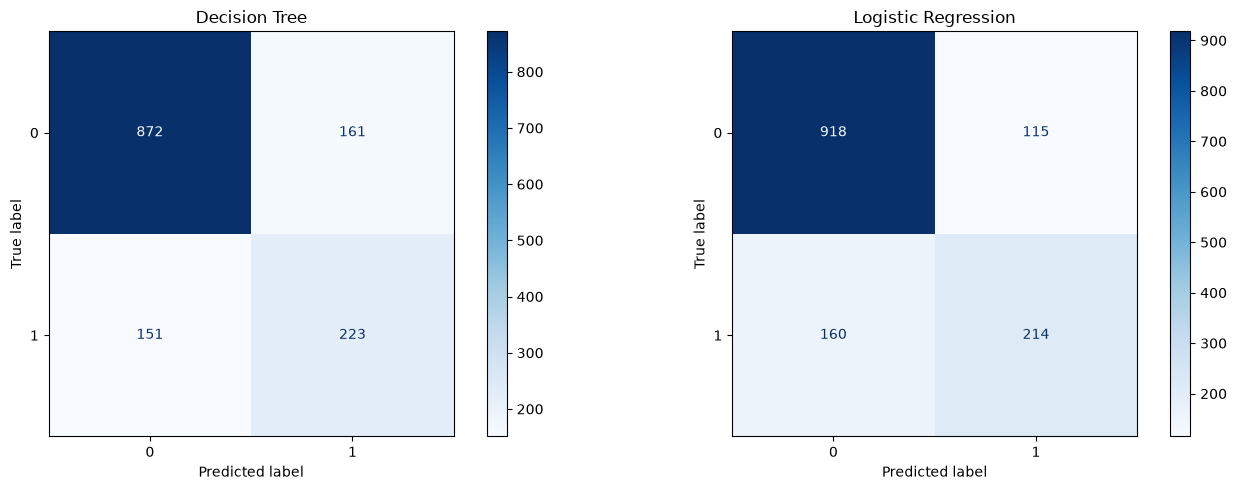

In [182]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[1], cmap='Blues')
axes[1].set_title('Logistic Regression')

plt.tight_layout()
plt.show()

### ROC Curves

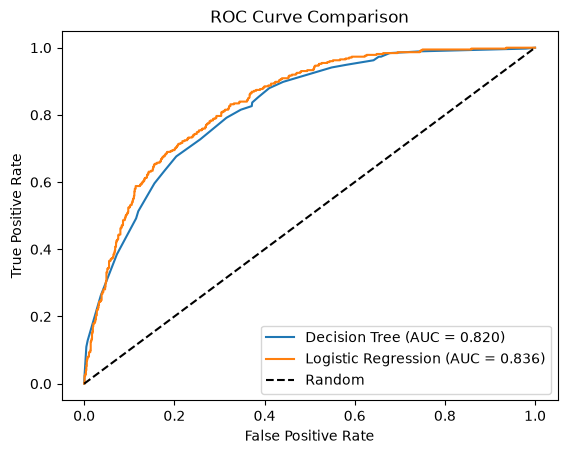

In [183]:
from sklearn.metrics import roc_curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## 9. Top 3 Features Driving Churn (Decision Tree)

                                Feature  Importance
4                                tenure    0.441283
11          InternetService_Fiber optic    0.338826
8                          TotalCharges    0.035817
28       PaymentMethod_Electronic check    0.026809
23  StreamingMovies_No internet service    0.026778
7                        MonthlyCharges    0.025650
26                    Contract_Two year    0.019312
15     OnlineBackup_No internet service    0.015402
14                   OnlineSecurity_Yes    0.015138
20                      TechSupport_Yes    0.012159


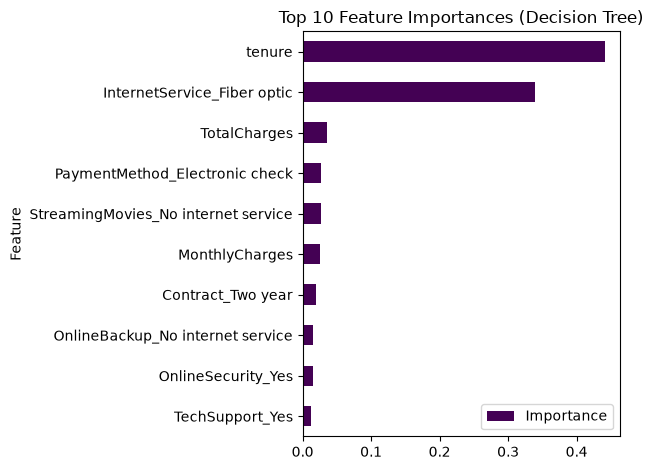


TOP 3 FEATURES DRIVING CHURN:
  tenure: 0.4413
  InternetService_Fiber optic: 0.3388
  TotalCharges: 0.0358


In [184]:
# Get feature importances
importances = pd.DataFrame({'Feature': X.columns, 'Importance': dt.feature_importances_}).sort_values('Importance', ascending=False)

print(importances.head(10))

# Plot top 10
importances.head(10).plot(x='Feature', y='Importance', kind='barh', colormap='viridis')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top 3 clearly
print("\nTOP 3 FEATURES DRIVING CHURN:")
for i, row in importances.head(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

## 10: Address Class Imbalance

In [187]:
class_distribution = pd.DataFrame({
    'Customers': y.value_counts().sort_index(),
    'Percentage': (y.value_counts(normalize=True).sort_index() * 100).round(1)
})

class_distribution.index = ['No Churn', 'Churn']
display(class_distribution)

print("CLASS IMBALANCE ANALYSIS:")
print(f"  - No Churn: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  - Churn:    {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print("\nNOTE: The dataset is imbalanced (~73% No vs ~27% Yes).")
print("This means the model could achieve 73% accuracy by predicting")
print("'No Churn' for everyone. We used stratified split and report")
print("F1-score and ROC-AUC to mitigate this bias.")
print("\nFUTURE IMPROVEMENT: Apply SMOTE oversampling or class_weight='balanced'")

,Customers,Percentage
No Churn,5163,73.4
Churn,1869,26.6


CLASS IMBALANCE ANALYSIS:
  - No Churn: 5163 (73.4%)
  - Churn:    1869 (26.6%)

NOTE: The dataset is imbalanced (~73% No vs ~27% Yes).
This means the model could achieve 73% accuracy by predicting
'No Churn' for everyone. We used stratified split and report
F1-score and ROC-AUC to mitigate this bias.

FUTURE IMPROVEMENT: Apply SMOTE oversampling or class_weight='balanced'


## 📊 Business Summary: Customer Churn Prediction

- The original dataset contains 7,043 telecom customers; after removing 11 records with missing `TotalCharges`, the analysis used 7,032 customers, of whom 26.6% were marked as churned.
- Two models—Decision Tree and Logistic Regression—were trained to predict customers at risk of leaving, with Logistic Regression performing best overall on the test set (80.5% accuracy, 0.609 F1-score, and 0.836 ROC-AUC).
- The Decision Tree provides an interpretable view of churn risk, with tenure, fiber-optic internet service, and total charges as its three most important predictive features.
- Customers with shorter tenure, month-to-month contracts, fiber-optic service, and higher monthly charges appear more likely to churn; class imbalance was addressed through a stratified split and evaluation using F1-score and ROC-AUC instead of accuracy alone.
- The retention team should prioritize these higher-risk customers with early support, targeted discounts, and contract-upgrade offers, while monitoring model performance before deployment.